# 🌌 Exoplanet Detection with Gradient Boosting

This notebook implements a supervised classification model to predict confirmed exoplanets based on data from the **Kepler Space Telescope**.  
The complete process includes data cleaning, feature selection, model training using a **scikit-learn Pipeline**, and performance evaluation through standard metrics.

### Dependencies Import

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    accuracy_score, f1_score
)
from sklearn.ensemble import GradientBoostingClassifier

import joblib

### Load and Dataset Exploration

In [2]:
# Upload CSV
df = pd.read_csv("/content/balanced_kepler_part1.csv")
print("Shape:", df.shape)
print("Columnas:", len(df.columns))
df.head(3)

Shape: (2812, 47)
Columnas: 47


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10397751,K02859.05,NaN,CANDIDATE,CANDIDATE,0.857,0,0,0,0,...,-144.0,4.555,0.088,-0.064,0.721,0.082,-0.073,288.83136,47.551991,13.851
1,1432789,K00992.01,Kepler-745 b,CONFIRMED,CANDIDATE,0.848,0,0,0,0,...,-78.0,4.280,0.137,-0.112,1.220,0.196,-0.176,291.49942,37.059280,15.214
2,3939150,K01215.01,Kepler-277 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-108.0,3.972,0.210,-0.084,1.857,0.264,-0.452,286.58316,39.077202,13.420


### Cleanning and variables selection

In [3]:
assert "koi_disposition" in df.columns, "No se encontró la columna 'koi_disposition' en el CSV."

# Class' Filter
df = df[df["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])].copy()
df["label"] = df["koi_disposition"].map({"CONFIRMED": 1, "FALSE POSITIVE": 0})

# Potential Features List
candidate_features = [
    "koi_period","koi_depth","koi_prad","koi_teq","koi_insol","koi_model_snr",
    "koi_steff","koi_slogg","koi_srad","koi_duration","koi_impact",
    "koi_fpflag_nt","koi_fpflag_ss","koi_fpflag_co","koi_fpflag_ec",
    "koi_score"
]
features = [c for c in candidate_features if c in df.columns]
if len(features) == 0:
    features = df.select_dtypes(include=[np.number]).columns.drop(["label"], errors="ignore").tolist()

X = df[features]
y = df["label"]

print("Features seleccionadas:", features)
print("\nBalance de clases:")
print(y.value_counts())

Features seleccionadas: ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_duration', 'koi_impact', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_score']

Balance de clases:
label
1    967
0    934
Name: count, dtype: int64


### Data Division

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((1520, 16), (381, 16))

### Model/Pipeline Construction and Trainning

In [5]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("gb", GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Model Evaluation

In [6]:
# Model Evaluation
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}
print("Métricas:", metrics)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["FALSE POSITIVE (0)", "CONFIRMED (1)"]))

cm = confusion_matrix(y_test, y_pred)

Métricas: {'accuracy': 0.989501312335958, 'f1': 0.9897435897435898, 'roc_auc': np.float64(0.9996416561001159), 'pr_auc': np.float64(0.9996561931690889)}

Classification Report:

                    precision    recall  f1-score   support

FALSE POSITIVE (0)       0.99      0.98      0.99       187
     CONFIRMED (1)       0.98      0.99      0.99       194

          accuracy                           0.99       381
         macro avg       0.99      0.99      0.99       381
      weighted avg       0.99      0.99      0.99       381



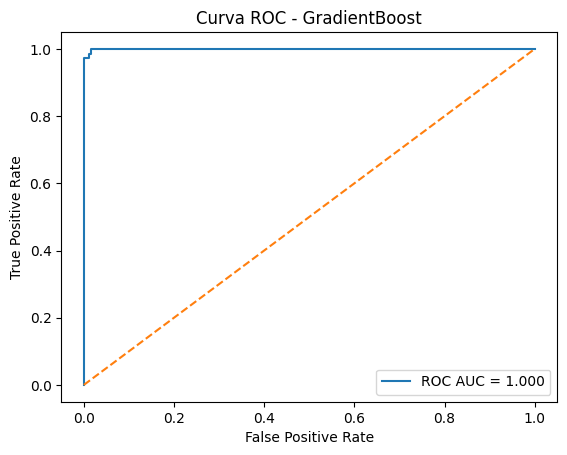

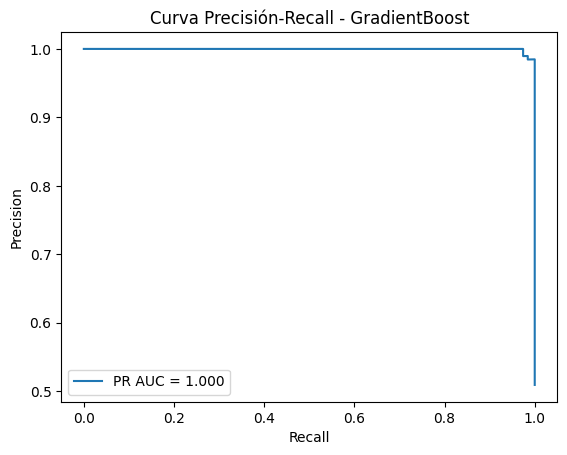

In [7]:
# Curves
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("Curva ROC - GradientBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(rec, prec, label=f"PR AUC = {metrics['pr_auc']:.3f}")
plt.title("Curva Precisión-Recall - GradientBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

In [11]:
# Get model for gb step
gb = model.named_steps["gb"]

# Verify if the model has the importants attributes
if hasattr(gb, "feature_importances_"):
    importances = gb.feature_importances_
    fi = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importances
    }).sort_values("importance", ascending=False)
    print("\nVariables más importantes:")
    print(fi.head(10).to_string(index=False))
else:
    print("El estimador no expone 'feature_importances_'.")



Variables más importantes:
      feature  importance
    koi_score    0.886029
koi_fpflag_ss    0.031447
koi_fpflag_nt    0.029054
koi_fpflag_co    0.015866
koi_model_snr    0.012919
   koi_impact    0.006808
     koi_prad    0.006088
   koi_period    0.002572
koi_fpflag_ec    0.001937
    koi_slogg    0.001875


### Usage and Save Model

In [12]:
# Save and download model
model_path = "gradientboost_exoplanets.pkl"
joblib.dump(model, model_path)
print("Modelo guardado en:", model_path)

# Download model in local
from google.colab import files
files.download(model_path)

Modelo guardado en: gradientboost_exoplanets.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Prediction Generation on New Datasets

In [13]:
from google.colab import files
import pandas as pd
import joblib

model_name = "/content/gradientboost_exoplanets.pkl"
csv_name   = "/content/test-data.csv"

In [14]:
# Upload trained model
model = joblib.load(model_name)

# Upload dataset
df_pred = pd.read_csv(csv_name)
print("Dataset cargado:", df_pred.shape)
df_pred.head()

Dataset cargado: (1125, 17)


,kepoi_name,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad
0,K02933.01,0.0,0,0,0,0,119.083304,1.2570,2.558,2951.0,22.19,240,0.78,18.9,4412,4.662,0.623
1,K01770.01,0.0,0,1,1,1,63.935496,1.2000,13.321,1250.6,2637.60,2590,10631.01,57.6,3626,0.684,97.410
2,K01804.01,1.0,0,0,0,0,5.907415,0.1770,1.016,5569.0,5.10,769,82.73,7.2,4963,4.585,0.690
3,K02433.06,NaN,0,0,0,0,6.063303,0.0214,3.275,200.7,1.64,1153,418.40,13.1,6308,4.353,1.153
4,K07929.01,0.0,0,0,1,1,3.044637,0.3220,6.656,47.0,0.68,1321,721.48,10.4,6181,4.474,0.980


In [15]:
# Get most-used features within model
features = model.named_steps['gb'].feature_importances_
X_cols = model.named_steps['imputer'].feature_names_in_
print("Features esperadas por el modelo:", list(X_cols))

X_pred = df_pred[list(X_cols)].copy()

Features esperadas por el modelo: ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_duration', 'koi_impact', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_score']


In [16]:
# Predictions
y_pred_proba = model.predict_proba(X_pred)[:, 1]
y_pred = model.predict(X_pred)

# Add results into DataFrame
df_pred["prob_confirme_planeta"] = y_pred_proba
df_pred["prediccion"] = y_pred

# Show first rows
df_pred.head()

,kepoi_name,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,prob_confirme_planeta,prediccion
0,K02933.01,0.0,0,0,0,0,119.083304,1.2570,2.558,2951.0,22.19,240,0.78,18.9,4412,4.662,0.623,0.762927,1
1,K01770.01,0.0,0,1,1,1,63.935496,1.2000,13.321,1250.6,2637.60,2590,10631.01,57.6,3626,0.684,97.410,0.000003,0
2,K01804.01,1.0,0,0,0,0,5.907415,0.1770,1.016,5569.0,5.10,769,82.73,7.2,4963,4.585,0.690,0.872758,1
3,K02433.06,NaN,0,0,0,0,6.063303,0.0214,3.275,200.7,1.64,1153,418.40,13.1,6308,4.353,1.153,0.973682,1
4,K07929.01,0.0,0,0,1,1,3.044637,0.3220,6.656,47.0,0.68,1321,721.48,10.4,6181,4.474,0.980,0.000035,0


In [17]:
# Download result in csv format
output_name = "predicciones_exoplanetas.csv"
df_pred.to_csv(output_name, index=False)

from google.colab import files
files.download(output_name)
print("Archivo de predicciones listo:", output_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivo de predicciones listo: predicciones_exoplanetas.csv
